# MovieLens PySpark Analysis

A simple PySpark data engineering pipeline demonstrating:
- **Bronze → Silver → Gold** medallion architecture
- Data cleansing (deduplication, timestamp normalization)
- Anomaly detection (user volume, movie distribution, temporal patterns)
- Gold-layer aggregations
- Three analytical deep-dives on the MovieLens dataset

Dataset: MovieLens Latest Small (~100K ratings, 9K movies, 600 users)

---
## 1. Setup

In [1]:
import os
import sys
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
from pyspark.sql.functions import col, count, desc, year as spark_year

In [2]:


# --- JAVA_HOME: auto-detect from the java executable on PATH ---
# This works regardless of JDK version or install location.
# We only set it if it isn't already defined (respects user's existing config).
if not os.environ.get("JAVA_HOME"):
    try:
        # "java -XshowSettings:property -version" prints java.home to stderr
        result = subprocess.run(
            ["java", "-XshowSettings:property", "-version"],
            capture_output=True, text=True
        )
        for line in result.stderr.splitlines():
            if "java.home" in line:
                java_home = line.split("=")[1].strip()
                os.environ["JAVA_HOME"] = java_home
                break
    except FileNotFoundError:
        raise EnvironmentError("Java not found on PATH. Please install JDK.")

# --- SPARK_HOME: always point at the pyspark bundled in our .venv ---
# Overrides any system-level SPARK_HOME that could cause version mismatches.
import pyspark
os.environ["SPARK_HOME"] = str(Path(pyspark.__file__).parent)

# --- HADOOP_HOME: needed on Windows for winutils.exe ---
# Leave unchanged if already set (e.g. on Linux/Mac this is not needed).
if not os.environ.get("HADOOP_HOME") and sys.platform == "win32":
    os.environ["HADOOP_HOME"] = r"C:\winutils"

# Add src/ to Python path so we can import our modules without installing the package
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root / "src"))

print(f"Project root : {project_root}")
print(f"JAVA_HOME    : {os.environ.get('JAVA_HOME')}")
print(f"SPARK_HOME   : {os.environ['SPARK_HOME']}")
print(f"HADOOP_HOME  : {os.environ.get('HADOOP_HOME', 'not set (ok on Linux/Mac)')}")

Project root : c:\Users\QK\Desktop\Python\langchain_course\Projects\movie_lens_pyspark
JAVA_HOME    : C:\Program Files\Java\jdk-21
SPARK_HOME   : c:\Users\QK\Desktop\Python\langchain_course\Projects\movie_lens_pyspark\.venv\Lib\site-packages\pyspark
HADOOP_HOME  : C:\winutils


In [3]:
# Import our custom modules
from spark_session import get_spark_session
from ingestion import load_movies, load_ratings, load_tags, load_links
from transformations import (
    deduplicate_ratings,
    normalize_timestamps,
    explode_genres,
    extract_release_year,
    build_gold_table,
)
from analytics import (
    top_genres_by_year,
    find_hidden_gems,
    build_inflight_catalog,
    detect_user_rating_anomalies,
    detect_movie_rating_anomalies,
    detect_temporal_anomalies,
)

In [4]:
# Create Spark session — local[*] uses all CPU cores on this machine
# 4gb ram is sufficient for this small dataset
spark = get_spark_session(app_name="MovieLensAnalysis", memory="4g")
print(f"Spark {spark.version} ready")

Spark 4.1.1 ready


---
## 2. Bronze Layer — Raw Data Ingestion

Load the four MovieLens CSV files with **explicit schemas** to avoid the extra data scan that `inferSchema=True` would require. This is a common production best practice.

| File | Contents |
|------|----------|
| `movies.csv` | movieId, title, pipe-separated genres |
| `ratings.csv` | userId, movieId, rating (0.5–5.0), Unix timestamp |
| `tags.csv` | userId, movieId, tag string, Unix timestamp |
| `links.csv` | movieId, imdbId, tmdbId |

In [5]:
# Paths are relative to project root
DATA_DIR = str(project_root / "data" / "raw")

movies_raw   = load_movies(spark,   f"{DATA_DIR}/movies.csv")
ratings_raw  = load_ratings(spark,  f"{DATA_DIR}/ratings.csv")
tags_raw     = load_tags(spark,     f"{DATA_DIR}/tags.csv")
links_raw    = load_links(spark,    f"{DATA_DIR}/links.csv")

print(f"Movies  : {movies_raw.count():>7,} rows.\n")

print(f"Ratings : {ratings_raw.count():>7,} rows")
print('Each user can rate multiple times.\n')

print(f"Tags    : {tags_raw.count():>7,} rows")
print("""Tags are user-generated metadata about movies. 
Each tag is typically a single word or short phrase. 
The meaning, value, and purpose of a particular tag is determined by each user. 
Examples: Tom Hardy, bloody.\n""")

print(f"Links   : {links_raw.count():>7,} rows")
print("""movieId is an identifier for movies used by <https://movielens.org>. E.g., the movie Toy Story has the link <https://movielens.org/movies/1>.
imdbId is an identifier for movies used by <http://www.imdb.com>. E.g., the movie Toy Story has the link <http://www.imdb.com/title/tt0114709/>.
tmdbId is an identifier for movies used by <https://www.themoviedb.org>. E.g., the movie Toy Story has the link <https://www.themoviedb.org/movie/862>.
""")

Movies  :   9,742 rows.

Ratings : 100,836 rows
Each user can rate multiple times.

Tags    :   3,683 rows
Tags are user-generated metadata about movies. 
Each tag is typically a single word or short phrase. 
The meaning, value, and purpose of a particular tag is determined by each user. 
Examples: Tom Hardy, bloody.

Links   :   9,742 rows
movieId is an identifier for movies used by <https://movielens.org>. E.g., the movie Toy Story has the link <https://movielens.org/movies/1>.
imdbId is an identifier for movies used by <http://www.imdb.com>. E.g., the movie Toy Story has the link <http://www.imdb.com/title/tt0114709/>.
tmdbId is an identifier for movies used by <https://www.themoviedb.org>. E.g., the movie Toy Story has the link <https://www.themoviedb.org/movie/862>.



In [6]:
# Inspect schema — timestamp is still a raw LongType at bronze layer
print("=== Ratings schema (Bronze) ===")
ratings_raw.printSchema()

print("\nSample movies:")
movies_raw.show(5, truncate=False)

=== Ratings schema (Bronze) ===
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)


Sample movies:
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5      |Father of the Bride Part II (1995)|Comedy                                     |
+-------+----------------------------------+-----------------------------------

In [7]:
print("Sample ratings:")
ratings_raw.show(5)

Sample ratings:
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
|     1|     47|   5.0|964983815|
|     1|     50|   5.0|964982931|
+------+-------+------+---------+
only showing top 5 rows


---
## 3. Silver Layer — Data Cleansing & Validation

Four cleansing steps:
1. **Deduplication** — keep only the latest rating per (user, movie) pair
2. **Timestamp normalization** — convert Unix longs to Spark `TimestampType` for time-based analysis
3. **Genre explosion** — split pipe-separated genre strings into one row per genre
4. **Release year extraction** — parse the year from movie titles (e.g. `Toy Story (1995)` → `1995`)

In [8]:
# Step 1: Deduplicate ratings
ratings_dedup = deduplicate_ratings(ratings_raw)
removed = ratings_raw.count() - ratings_dedup.count()
print(f"Duplicate rows removed: {removed}")

Duplicate rows removed: 0


In [9]:
# Step 2: Normalize timestamps from Unix epoch (long) → TimestampType
ratings_silver, tags_silver = normalize_timestamps(ratings_dedup, tags_raw)

print("=== Ratings schema (Silver) — timestamp is now TimestampType ===")
ratings_silver.printSchema()

=== Ratings schema (Silver) — timestamp is now TimestampType ===
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: timestamp (nullable = true)



In [10]:
# Verify timestamp range looks reasonable
from pyspark.sql.functions import min as spark_min, max as spark_max

ratings_silver.agg(
    spark_min("timestamp").alias("earliest"),
    spark_max("timestamp").alias("latest")
).show(truncate=False)

print('Data goes from 1996 to 2018, as stated in the dataset readme file.')

+-------------------+-------------------+
|earliest           |latest             |
+-------------------+-------------------+
|1996-03-30 02:36:55|2018-09-24 22:27:30|
+-------------------+-------------------+

Data goes from 1996 to 2018, as stated in the dataset readme file.


In [11]:
# Step 3: Explode pipe-separated genres into individual rows
# e.g. "Action|Comedy|Romance" becomes three rows: Action, Comedy, Romance
# without this once-off wide operation, we would have to continually do operations 
# such as col("genres").contains("Action") which are very slow and not scalable. 
movies_exploded = explode_genres(movies_raw)

print(f"Original movie rows     : {movies_raw.count():,}")
print(f"Exploded movie-genre rows: {movies_exploded.count():,}")

movies_exploded.show(8, truncate=False)

Original movie rows     : 9,742
Exploded movie-genre rows: 22,050
+-------+----------------+-------------------------------------------+---------+
|movieId|title           |genres                                     |genre    |
+-------+----------------+-------------------------------------------+---------+
|1      |Toy Story (1995)|Adventure|Animation|Children|Comedy|Fantasy|Adventure|
|1      |Toy Story (1995)|Adventure|Animation|Children|Comedy|Fantasy|Animation|
|1      |Toy Story (1995)|Adventure|Animation|Children|Comedy|Fantasy|Children |
|1      |Toy Story (1995)|Adventure|Animation|Children|Comedy|Fantasy|Comedy   |
|1      |Toy Story (1995)|Adventure|Animation|Children|Comedy|Fantasy|Fantasy  |
|2      |Jumanji (1995)  |Adventure|Children|Fantasy                 |Adventure|
|2      |Jumanji (1995)  |Adventure|Children|Fantasy                 |Children |
|2      |Jumanji (1995)  |Adventure|Children|Fantasy                 |Fantasy  |
+-------+----------------+-----------------

In [12]:
# Step 4: Extract release year from movie titles ("Movie Title (YYYY)")
movies_with_year = extract_release_year(movies_raw)

null_years = movies_with_year.filter(col("release_year").isNull()).count()
print(f"Movies with parsed release year : {movies_with_year.count() - null_years:,}")
print(f"Movies with no parseable year   : {null_years}")
print()
movies_with_year.select("title", "release_year").show(10, truncate=False)

Movies with parsed release year : 9,728
Movies with no parseable year   : 14

+----------------------------------+------------+
|title                             |release_year|
+----------------------------------+------------+
|Toy Story (1995)                  |1995        |
|Jumanji (1995)                    |1995        |
|Grumpier Old Men (1995)           |1995        |
|Waiting to Exhale (1995)          |1995        |
|Father of the Bride Part II (1995)|1995        |
|Heat (1995)                       |1995        |
|Sabrina (1995)                    |1995        |
|Tom and Huck (1995)               |1995        |
|Sudden Death (1995)               |1995        |
|GoldenEye (1995)                  |1995        |
+----------------------------------+------------+
only showing top 10 rows


In [13]:
# Unique genres present in the dataset
movies_exploded.select("genre").distinct().orderBy("genre").show(20)

+-----------+
|      genre|
+-----------+
|     Action|
|  Adventure|
|  Animation|
|   Children|
|     Comedy|
|      Crime|
|Documentary|
|      Drama|
|    Fantasy|
|  Film-Noir|
|     Horror|
|       IMAX|
|    Musical|
|    Mystery|
|    Romance|
|     Sci-Fi|
|   Thriller|
|        War|
|    Western|
+-----------+



---
## 4. Anomaly Detection

Three anomaly checks using z-scores (>3σ from mean = anomalous):
- **User volume** — users with suspiciously many ratings (bot-like behaviour)
- **Movie distribution** — movies with suspiciously low rating variance (unnaturally uniform ratings)
- **Temporal** — days with unusually high rating volume

In [14]:
# --- 4a. User rating volume anomalies ---
user_anomalies = detect_user_rating_anomalies(ratings_silver)

total_users = user_anomalies.count()
flagged_users = user_anomalies.filter(col("is_anomaly") == True)
print(f"Total users             : {total_users}")
print(f"Anomalous users (|z| > 3): {flagged_users.count()} ({flagged_users.count() / total_users:.1%})")

print("\nTop anomalous users:")
flagged_users.show(5)

Total users             : 610
Anomalous users (|z| > 3): 14 (2.3%)

Top anomalous users:
+------+------------+------------------+----------+
|userId|rating_count|           z_score|is_anomaly|
+------+------------+------------------+----------+
|   414|        2698| 9.398432498307193|      true|
|   599|        2478| 8.582047152771803|      true|
|   474|        2108|7.2090354352804695|      true|
|   448|        1864| 6.303589870232129|      true|
|   274|        1346|  4.38137346574426|      true|
+------+------------+------------------+----------+
only showing top 5 rows


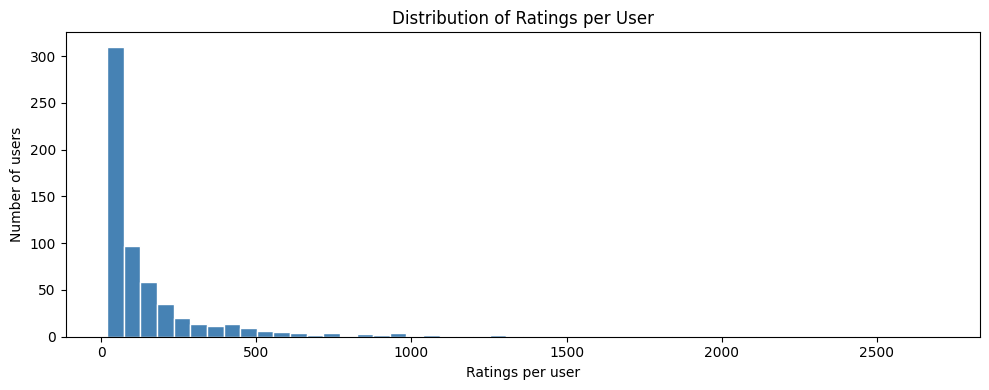

In [15]:
# Visualise user rating distribution (use pandas for small aggregates)
user_counts_pd = user_anomalies.select("rating_count").toPandas()

plt.figure(figsize=(10, 4))
plt.hist(user_counts_pd["rating_count"], bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Ratings per user")
plt.ylabel("Number of users")
plt.title("Distribution of Ratings per User")
plt.tight_layout()
plt.show()

In [16]:
# --- 4b. Movie rating distribution anomalies ---
# Flag movies with abnormally low rating variance (variance z-score < -3)
# i.e. their ratings are suspiciously uniform compared to all other movies
movie_anomalies = detect_movie_rating_anomalies(ratings_silver)

flagged_movies = movie_anomalies.filter(col("is_suspicious") == True)
print(f"Movies with suspiciously low rating variance (z < -3): {flagged_movies.count()}")

flagged_movies.join(movies_raw.select("movieId", "title"), on="movieId", how="inner") \
    .select("title", "rating_count", "avg_rating", "rating_stddev", "variance_z_score") \
    .show(10, truncate=False)

Movies with suspiciously low rating variance (z < -3): 2
+----------------------+------------+------------------+------------------+-------------------+
|title                 |rating_count|avg_rating        |rating_stddev     |variance_z_score   |
+----------------------+------------+------------------+------------------+-------------------+
|Cinderella Man (2005) |17          |4.088235294117647 |0.2642970699354622|-3.5342508528791696|
|Made in America (1993)|11          |2.8636363636363638|0.3233348953414316|-3.2096661240194346|
+----------------------+------------+------------------+------------------+-------------------+



In [17]:
# --- 4c. Temporal anomalies ---
# Days where rating volume is > 3σ above the daily average
temporal_anomalies = detect_temporal_anomalies(ratings_silver)

flagged_dates = temporal_anomalies.filter(col("is_anomaly") == True)
print(f"Anomalous dates: {flagged_dates.count()}")

flagged_dates.show(10)

Anomalous dates: 75
+----------+------------+------------------+----------+
|      date|rating_count|           z_score|is_anomaly|
+----------+------------+------------------+----------+
|2017-06-27|        1567| 22.84638203839116|      true|
|2017-05-04|         876|12.610851552088157|      true|
|2007-05-15|         838| 12.04797143851433|      true|
|2015-11-15|         770|11.040712287908535|      true|
|2000-08-08|         734|10.507457443470173|      true|
|2015-06-29|         692| 9.885326791625417|      true|
|2000-06-20|         662| 9.440947754593449|      true|
|2000-04-17|         582| 8.255936989174867|      true|
|2009-11-17|         574| 8.137435912633007|      true|
|2006-09-18|         548| 7.752307413871969|      true|
+----------+------------+------------------+----------+
only showing top 10 rows


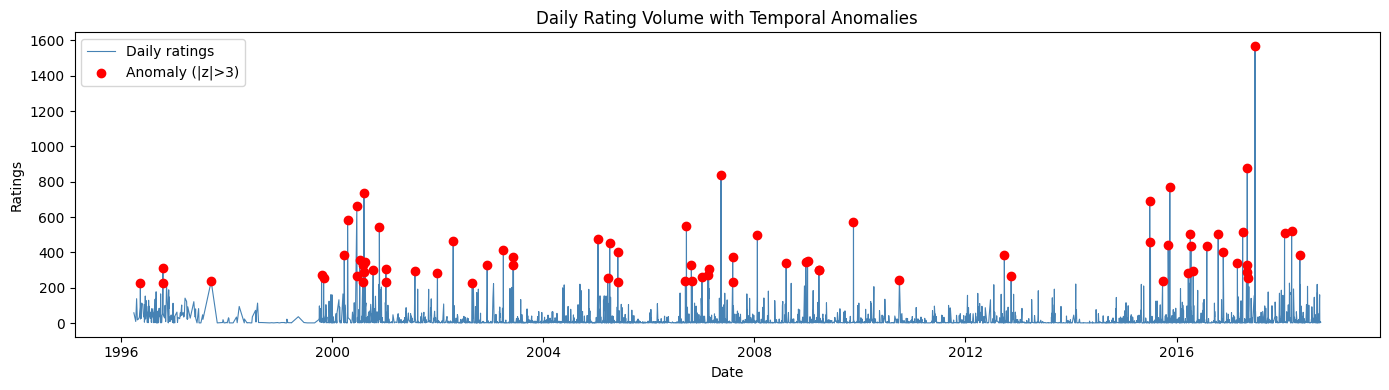

In [18]:
# Visualise daily ratings volume with anomaly markers
daily_pd = temporal_anomalies.orderBy("date").toPandas()
daily_pd["date"] = pd.to_datetime(daily_pd["date"])

plt.figure(figsize=(14, 4))
plt.plot(daily_pd["date"], daily_pd["rating_count"], linewidth=0.8, color="steelblue", label="Daily ratings")
anomalous = daily_pd[daily_pd["is_anomaly"] == True]
plt.scatter(anomalous["date"], anomalous["rating_count"], color="red", zorder=5, label="Anomaly (|z|>3)")
plt.xlabel("Date")
plt.ylabel("Ratings")
plt.title("Daily Rating Volume with Temporal Anomalies")
plt.legend()
plt.tight_layout()
plt.show()

Observations:
- These are likely just noise and the spikes seem random. 
- In production, we can deep dive into the ratings (e.g. all 1000 extra ratings for that day are from a single flight or for a single movie), then we have to check if there are any issues such as bots or errors in the data pipelines.

---
## 5. Gold Layer — Aggregate Business Table

Build the Gold table: **avg_rating, rating_count, tag_count per movie per genre**.

This is the business-ready layer — queries in sections 6–8 build on top of this.

In [19]:
gold_df = build_gold_table(ratings_silver, tags_silver, movies_exploded)

print(f"Gold table rows (movie x genre): {gold_df.count():,}")
print("Note: Each Movie can appear multiple times if it has multiple genres.")
print()
gold_df.show(5)

Gold table rows (movie x genre): 22,012
Note: Each Movie can appear multiple times if it has multiple genres.

+-------+---------+------------------+------------+---------+
|movieId|    genre|        avg_rating|rating_count|tag_count|
+-------+---------+------------------+------------+---------+
|      1|Adventure|3.9209302325581397|         215|        3|
|     47| Thriller|3.9753694581280787|         203|        3|
|     70|   Comedy|3.5090909090909093|          55|        0|
|     70|   Action|3.5090909090909093|          55|        0|
|    157|      War|2.8636363636363638|          11|        0|
+-------+---------+------------------+------------+---------+
only showing top 5 rows


In [20]:
# Summary statistics for the gold table
gold_df.describe(["avg_rating", "rating_count", "tag_count"]).show()

+-------+------------------+------------------+------------------+
|summary|        avg_rating|      rating_count|         tag_count|
+-------+------------------+------------------+------------------+
|  count|             22012|             22012|             22012|
|   mean| 3.262501346761769|12.467426858077411|0.4493912411411957|
| stddev|0.8481099871751382|25.428238683962945|3.0372621288752626|
|    min|               0.5|                 1|                 0|
|    max|               5.0|               329|               181|
+-------+------------------+------------------+------------------+



In [21]:
# Average rating by genre — quick genre quality ranking
from pyspark.sql.functions import avg, round as spark_round

gold_df.groupBy("genre").agg(
    spark_round(avg("avg_rating"), 3).alias("mean_avg_rating"),
    count("*").alias("movie_count")
).orderBy(desc("mean_avg_rating")).show(25)

+-----------+---------------+-----------+
|      genre|mean_avg_rating|movie_count|
+-----------+---------------+-----------+
|Documentary|          3.782|        438|
|  Film-Noir|           3.67|         85|
|        War|          3.572|        381|
|  Animation|          3.497|        610|
|      Drama|          3.421|       4349|
|    Western|          3.383|        167|
|    Romance|          3.365|       1591|
|    Mystery|           3.33|        573|
|       IMAX|          3.312|        158|
|      Crime|          3.302|       1196|
|    Musical|          3.296|        333|
|    Fantasy|          3.219|        778|
|  Adventure|          3.215|       1262|
|     Comedy|          3.182|       3753|
|   Thriller|          3.156|       1889|
|   Children|          3.108|        664|
|     Sci-Fi|          3.103|        980|
|     Action|          3.094|       1828|
|     Horror|          2.919|        977|
+-----------+---------------+-----------+



---
## Analysis Top 10 Genres by Total Ratings & Popularity Over Time

*What are the top 10 genres by total number of ratings, and how has their popularity evolved over time?*

In [22]:
genre_year_df = top_genres_by_year(ratings_silver, movies_exploded)

# Show total ranking
from pyspark.sql.functions import sum as spark_sum
genre_year_df.groupBy("genre", "rank") \
    .agg(spark_sum("rating_count").alias("total_ratings")) \
    .orderBy("rank").show(10)

+---------+----+-------------+
|    genre|rank|total_ratings|
+---------+----+-------------+
|    Drama|   1|        41928|
|   Comedy|   2|        39053|
|   Action|   3|        30635|
| Thriller|   4|        26452|
|Adventure|   5|        24161|
|  Romance|   6|        18124|
|   Sci-Fi|   7|        17243|
|    Crime|   8|        16681|
|  Fantasy|   9|        11834|
| Children|  10|         9208|
+---------+----+-------------+



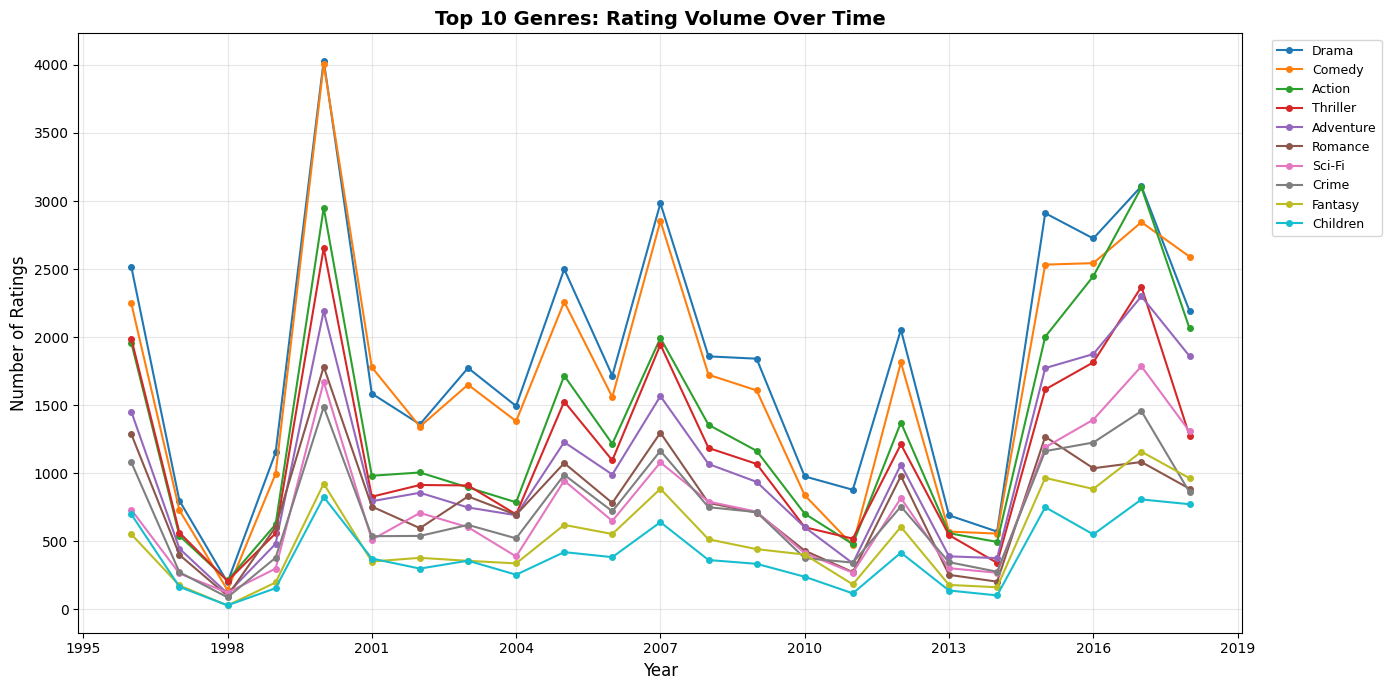

In [23]:
# Convert to pandas for visualization (small result set — safe)
genre_year_pd = genre_year_df.filter(col("year").isNotNull()).toPandas()

# Ordered genre list by total volume
genre_order = (
    genre_year_pd.groupby("genre")["rating_count"]
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 7))
for genre in genre_order:
    gd = genre_year_pd[genre_year_pd["genre"] == genre].sort_values("year")
    ax.plot(gd["year"], gd["rating_count"], marker="o", markersize=4, label=genre)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Ratings", fontsize=12)
ax.set_title("Top 10 Genres: Rating Volume Over Time", fontsize=14, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Observations:
- Comedy, Drama and Action have the highest activity.
- Horror and Documentary have lower but consistent activity.
- Crime has lower activity, perhaps because passengers do not want to watch movies that are too heavy in nature on flights.
- Children has lower consistent activity but a good mix of children movies are still necessary in IFE for the young ones.

---
## Analysis : Recent Releases — Top Movies from the Past Year

*Among movies released within one year of the latest rating in the dataset (2018-09-24), which titles have both the highest ratings and the most ratings?*

Latest rating date is **2018-09-24**, so we look at movies with `release_year >= 2017`.

In [24]:
# Derive cutoff: latest rating year minus 1
latest_year = ratings_silver.agg(
    spark_max(spark_year("timestamp")).alias("latest_year")
).collect()[0]["latest_year"]

cutoff_year = latest_year - 1
print(f"Latest rating year : {latest_year}")
print(f"Cutoff year (>=)   : {cutoff_year}")

# Compute movie-level metrics
recent_metrics = ratings_silver.groupBy("movieId").agg(
    avg("rating").alias("avg_rating"),
    count("rating").alias("rating_count")
)

# Join with movies to get release_year, filter to recent releases
recent_top = (
    recent_metrics
    .join(movies_with_year.select("movieId", "title", "release_year"), on="movieId", how="inner")
    .filter(col("release_year") >= cutoff_year)
    .orderBy(desc("rating_count"), desc("avg_rating"))
)

print(f"\nRecent movies (release_year >= {cutoff_year}) with ratings: {recent_top.count()}")
print()
recent_top.select("title", "release_year", "avg_rating", "rating_count").show(20, truncate=False)

Latest rating year : 2018
Cutoff year (>=)   : 2017

Recent movies (release_year >= 2017) with ratings: 188

+-------------------------------------------------------+------------+------------------+------------+
|title                                                  |release_year|avg_rating        |rating_count|
+-------------------------------------------------------+------------+------------------+------------+
|Guardians of the Galaxy 2 (2017)                       |2017        |3.925925925925926 |27          |
|Logan (2017)                                           |2017        |4.28              |25          |
|Thor: Ragnarok (2017)                                  |2017        |4.025             |20          |
|Blade Runner 2049 (2017)                               |2017        |3.8055555555555554|18          |
|Untitled Spider-Man Reboot (2017)                      |2017        |4.15625           |16          |
|Get Out (2017)                                         |2017      

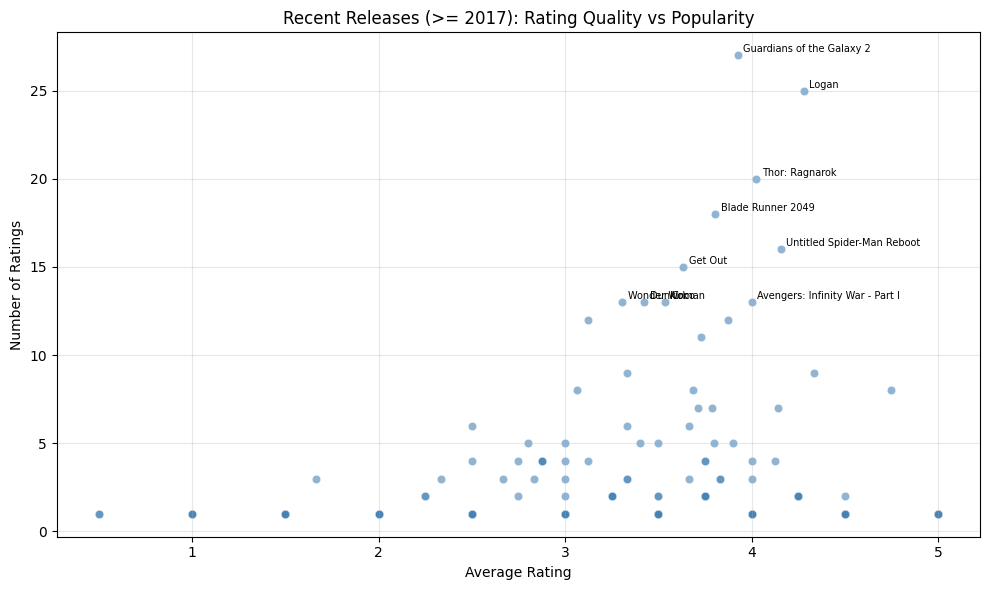

In [25]:
# Visualise: scatter of rating_count vs avg_rating, sized by rating_count
recent_pd = recent_top.toPandas()

plt.figure(figsize=(10, 6))
sc = plt.scatter(
    recent_pd["avg_rating"],
    recent_pd["rating_count"],
    alpha=0.6,
    color="steelblue",
    edgecolors="white",
    linewidths=0.4
)

# Label the top 10 by rating_count
for _, row in recent_pd.head(10).iterrows():
    plt.annotate(
        row["title"].replace(f" ({int(row['release_year'])})", ""),
        (row["avg_rating"], row["rating_count"]),
        fontsize=7,
        xytext=(4, 2),
        textcoords="offset points"
    )

plt.xlabel("Average Rating")
plt.ylabel("Number of Ratings")
plt.title(f"Recent Releases (>= {cutoff_year}): Rating Quality vs Popularity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Observations:
- Essentially, we are looking for blockbusters here: popular movies released in the past year with good ratings (top right quadrant).
- A better approach will be to take past 12 months instead of latest year - 1, but the dataset's movie titles have only release years and not the exact date, hence the simplifications.

---
## Analysis : Hidden Gems

*Identify movies with fewer than 50 ratings but an average rating above 4.0. Which genres are over-represented in this segment compared to the overall genre distribution?*

In [26]:
hidden_gems_df, genre_comparison_df = find_hidden_gems(ratings_silver, movies_raw, movies_exploded)

print(f"Hidden gems found: {hidden_gems_df.count()}")
print()
hidden_gems_df.show(20, truncate=False)

Hidden gems found: 284

+-------+-----------------+------------+------------------------------------------------------------------------------+
|movieId|avg_rating       |rating_count|title                                                                         |
+-------+-----------------+------------+------------------------------------------------------------------------------+
|6460   |4.9              |5           |Trial, The (Procès, Le) (1962)                                                |
|177593 |4.75             |8           |Three Billboards Outside Ebbing, Missouri (2017)                              |
|31364  |4.7              |5           |Memories of Murder (Salinui chueok) (2003)                                    |
|2239   |4.666666666666667|6           |Swept Away (Travolti da un insolito destino nell'azzurro mare d'Agosto) (1975)|
|4334   |4.6              |5           |Yi Yi (2000)                                                                  |
|1041   |4.59090

In [27]:
# Genre over-representation: ratio > 1 means that genre appears more in hidden gems
# than its share in the overall dataset would predict
print("Genre over-representation in hidden gems:")
genre_comparison_df.show(20)

Genre over-representation in hidden gems:
+-----------+------------+-------------+------------+--------------------+-------------------+
|      genre|hidden_count|overall_count|hidden_ratio|       overall_ratio|over_representation|
+-----------+------------+-------------+------------+--------------------+-------------------+
|  Film-Noir|          12|          870|     0.01875|0.003170172683314...|  5.914504310344827|
|Documentary|          13|         1219|   0.0203125|0.004441885633287542|  4.572945293273175|
|    Western|          14|         1930|    0.021875|0.007032681929651...| 3.1104776554404143|
|        War|          26|         4859|    0.040625|0.017705596630142876|  2.294472242230912|
|      Drama|         200|        41928|      0.3125| 0.15278046007586552| 2.0454186343255105|
|    Mystery|          27|         7674|   0.0421875|0.027963109392820835| 1.5086841526583268|
|  Animation|          20|         6988|     0.03125|0.025463410012644253| 1.2272511805953061|
|      C

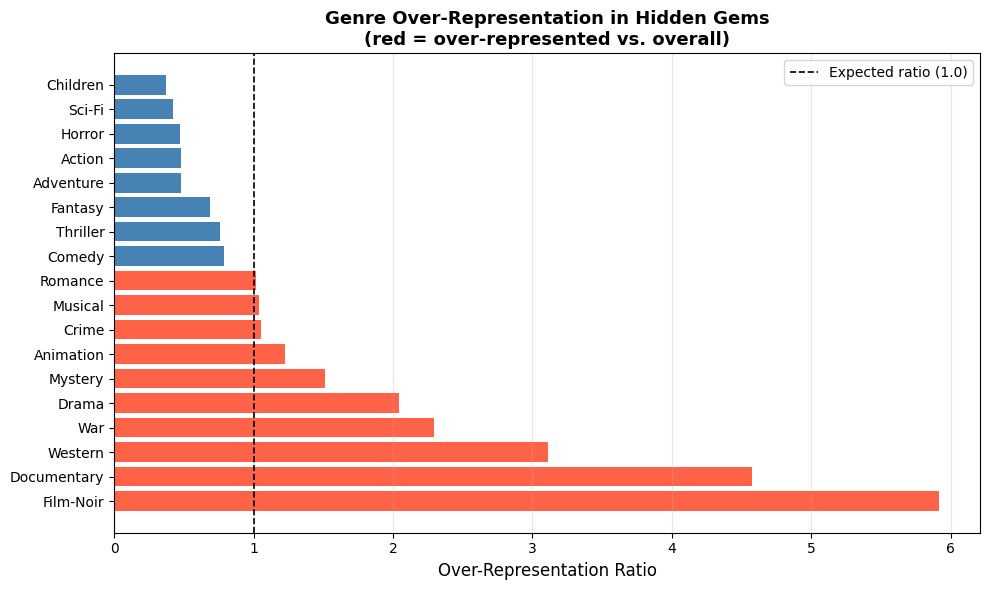

In [28]:
genre_comp_pd = genre_comparison_df.toPandas().head(18)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["tomato" if v > 1 else "steelblue" for v in genre_comp_pd["over_representation"]]
ax.barh(genre_comp_pd["genre"], genre_comp_pd["over_representation"], color=colors)
ax.axvline(x=1, color="black", linestyle="--", linewidth=1.2, label="Expected ratio (1.0)")
ax.set_xlabel("Over-Representation Ratio", fontsize=12)
ax.set_title("Genre Over-Representation in Hidden Gems\n(red = over-represented vs. overall)", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

---
## Analysis : Inflight Entertainment Catalog

*Build a 100-movie catalog optimised for passenger satisfaction using a three-section strategy:*

| Section | Count | Logic |
|---|---|---|
| **Recent Blockbusters** | 10 | Top composite-scored movies released in the past year (≥ 10 ratings) |
| **Hidden Gems** | 10 | Top hidden gems (5–50 ratings, avg > 4.0) not already in blockbusters |
| **Genre-Weighted Fill** | 80 | Proportionally allocated across 12 genres by composite score |

**Composite score** = 60% normalised avg rating + 40% normalised rating count (balances quality vs popularity).

Genre allocations for the fill section: Drama 12, Comedy 12, Action 10, Thriller 8, Adventure 7, Romance 6, Sci-Fi 6, Crime 6, Children 5, Fantasy 4, Documentary 2, Film-Noir 2.

In [ ]:
catalog_df = build_inflight_catalog(
    ratings_df=ratings_silver,
    movies_df=movies_raw,
    movies_with_year_df=movies_with_year,
    movies_exploded_df=movies_exploded,
    hidden_gems_df=hidden_gems_df,
    cutoff_year=cutoff_year
)

# Summary by section
print(f"Total movies in catalog: {catalog_df.count()}\n")
print("Breakdown by selection reason:")
catalog_df.groupBy("selection_reason").agg(
    count("*").alias("count")
).orderBy("selection_reason").show()

print("\nRecent Blockbusters:")
catalog_df.filter(col("selection_reason") == "recent_blockbuster") \
    .select("title", "avg_rating", "rating_count", "composite_score") \
    .show(10, truncate=False)

print("Hidden Gems:")
catalog_df.filter(col("selection_reason") == "hidden_gem") \
    .select("title", "avg_rating", "rating_count", "composite_score") \
    .show(10, truncate=False)

Total movies in catalog: 100

Breakdown by selection reason:
+------------------+-----+
|  selection_reason|count|
+------------------+-----+
|        genre_fill|   80|
|        hidden_gem|   10|
|recent_blockbuster|   10|
+------------------+-----+


Recent Blockbusters:
+--------------------------------------+------------------+------------+-------------------+
|title                                 |avg_rating        |rating_count|composite_score    |
+--------------------------------------+------------------+------------+-------------------+
|Logan (2017)                          |4.28              |25          |0.5332682926829269 |
|Untitled Spider-Man Reboot (2017)     |4.15625           |16          |0.5057926829268292 |
|Thor: Ragnarok (2017)                 |4.025             |20          |0.4931707317073171 |
|Guardians of the Galaxy 2 (2017)      |3.925925925925926 |27          |0.4884974405299608 |
|Avengers: Infinity War - Part I (2018)|4.0               |13          |0.48

In [30]:
# Analyze genre coverage of the selected catalog
from pyspark.sql.functions import split, explode as spark_explode

catalog_genres = catalog_df.withColumn(
    "genre",
    spark_explode(split(col("genres"), r"\|"))
).filter(col("genre") != "(no genres listed)")

catalog_genre_dist = catalog_genres.groupBy("genre").agg(
    count("*").alias("movie_count")
).orderBy(desc("movie_count"))

print("Genre distribution in the inflight catalog:")
catalog_genre_dist.show(25)

Genre distribution in the inflight catalog:
+-----------+-----------+
|      genre|movie_count|
+-----------+-----------+
|      Drama|         43|
|     Action|         36|
|  Adventure|         33|
|   Thriller|         30|
|      Crime|         25|
|     Sci-Fi|         24|
|     Comedy|         18|
|    Romance|         13|
|    Fantasy|         12|
|    Mystery|         11|
|   Children|          8|
|  Animation|          8|
|        War|          8|
|     Horror|          6|
|       IMAX|          5|
|    Musical|          3|
|Documentary|          2|
|  Film-Noir|          2|
|    Western|          1|
+-----------+-----------+



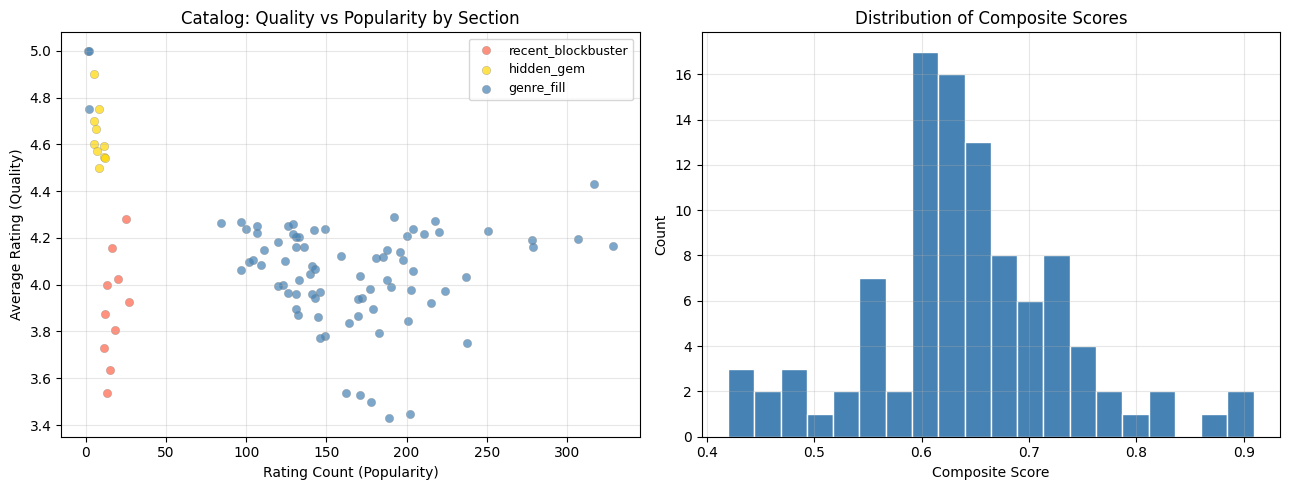

In [31]:
# Score distribution coloured by selection reason
catalog_pd = catalog_df.select("avg_rating", "rating_count", "composite_score", "selection_reason").toPandas()

colour_map = {
    "recent_blockbuster": "tomato",
    "hidden_gem": "gold",
    "genre_fill": "steelblue"
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for reason, colour in colour_map.items():
    subset = catalog_pd[catalog_pd["selection_reason"] == reason]
    axes[0].scatter(
        subset["rating_count"], subset["avg_rating"],
        c=colour, label=reason, alpha=0.7, edgecolors="grey", linewidths=0.3
    )
axes[0].set_xlabel("Rating Count (Popularity)")
axes[0].set_ylabel("Average Rating (Quality)")
axes[0].set_title("Catalog: Quality vs Popularity by Section")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].hist(catalog_pd["composite_score"], bins=20, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Composite Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Composite Scores")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Cleanup

In [32]:
# Always stop the Spark session when done to release resources
spark.stop()
print("Spark session stopped.")

Spark session stopped.
